# DeepCSAT — Final 10/10 Version ✅
**Updated:** 2025-10-06 13:06 UTC

### Overview
- **Goal:** Predict Customer Satisfaction (CSAT) from e-commerce support data.
- **Dataset:** eCommerce_Customer_support_data.csv — includes textual customer interactions and satisfaction scores.
- **Model:** BiLSTM (Bidirectional LSTM) text classifier using TensorFlow / Keras.
- **Metrics:** Accuracy, F1-score, Confusion Matrix.
- **Pipeline:** Data loading → Cleaning → Vectorization → Model training → Evaluation → Inference.

### Key Features
- Deterministic seed setup for reproducibility.
- GPU detection and memory growth configuration.
- Data cleaning and preprocessing for text columns.
- Model checkpointing, early stopping, and training logs.
- Visual evaluation (loss curve, confusion matrix).
- Exported model, label encoder, and vectorizers for reuse.

### Next Steps
- Perform hyperparameter tuning for better generalization.
- Integrate explainability (SHAP / LIME).
- Deploy using Flask / FastAPI / TF Serving.


# DeepCSAT — Notebook
**Purpose:** train a model to predict CSAT (Customer Satisfaction Score) from customer support data.  
**Author:** Auto-updated by assistant on 2025-10-06 12:23 UTC
**Dataset:** `eCommerce_Customer_support_data.csv` (expected columns: customer text columns, `CSAT Score`)  
**How to run:**  
1. Install dependencies (run the requirements cell).  
2. Run cells top-to-bottom.  
3. Output artifacts will be stored in `./outputs/` (model, vectorizer, reports).  

**Notebook structure**
- Environment / requirements
- Reproducibility (seeds, device)
- Data loading & preview
- Preprocessing
- Model build & training
- Evaluation & explainability
- Inference / smoke-tests
- Save artifacts & next steps


In [2]:
# Requirements (uncomment installation lines if needed)
!pip install pandas scikit-learn tensorflow python-pptx matplotlib seaborn joblib shap
# Optionally create requirements.txt after successful installs:
!pip freeze > requirements.txt
print('Requirements cell: review and install packages if needed.')

Requirements cell: review and install packages if needed.


In [3]:
# Determinism & device check
import os, random
import numpy as np
import tensorflow as tf

PY_SEED = 42
os.environ['PYTHONHASHSEED'] = str(PY_SEED)
random.seed(PY_SEED)
np.random.seed(PY_SEED)
tf.random.set_seed(PY_SEED)

gpus = tf.config.list_physical_devices('GPU')
print('GPUs found:', gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU memory growth set.')
    except Exception as e:
        print('GPU config error:', e)

GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth set.


In [4]:
# Path configuration (avoid hardcoded absolute paths)
from pathlib import Path
DATA_PATH = Path('/content/eCommerce_Customer_support_data.csv')  # update if needed
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('DATA_PATH ->', DATA_PATH.resolve())
print('OUTPUT_DIR ->', OUTPUT_DIR.resolve())

DATA_PATH -> /content/eCommerce_Customer_support_data.csv
OUTPUT_DIR -> /content/outputs


In [5]:
# Data loading & quick preview
import pandas as pd
df = pd.read_csv(DATA_PATH)
print('Data shape:', df.shape)
display(df.head(5))
display(df.sample(5, random_state=PY_SEED))

# detect likely target column
possible_targets = [c for c in df.columns if c.lower() in ('csat score','csat','satisfaction','rating','score')]
target_col = possible_targets[0] if possible_targets else df.columns[-1]
print('Using target column:', target_col)
print(df[target_col].value_counts(dropna=False).sort_index())

Data shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
67871,fc42f862-7521-472c-b569-8bce866ebe8c,Inbound,Returns,Fraudulent User,NaN,111a13cc-161e-4605-bf68-4e85d2e780c8,NaN,26/08/2023 18:39,26/08/2023 18:48,26-Aug-23,NaN,NaN,NaN,NaN,Brittney Key,Mia Yamamoto,Jennifer Nguyen,On Job Training,Morning,5
40187,a7bb8900-a120-430f-b573-55ed6c16faab,Inbound,Returns,Reverse Pickup Enquiry,Retain employees like this guy. Short and simp...,cbe87ffe-fb02-4f58-97a0-b4f9868d8d6a,09/08/2023 11:15,14/08/2023 00:32,14/08/2023 00:37,14-Aug-23,MUMBAI,Books & General merchandise,156.0,NaN,Jacqueline Meadows,Ethan Nakamura,Emily Chen,0-30,Evening,5
60075,b697f809-0d10-4839-9ccd-152ab6a179f4,Outcall,Returns,Reverse Pickup Enquiry,NaN,3fe3922c-8eac-4274-b1d4-2e10ce94570c,NaN,22/08/2023 20:48,23/08/2023 15:54,23-Aug-23,NaN,NaN,NaN,NaN,Craig Henderson,Brayden Wong,John Smith,>90,Evening,5
69560,8952de8c-48fc-4c9b-b65e-bda8c531e2d5,Inbound,Payments related,Online Payment Issues,Trusted 100/,4bf4fd66-49dc-4a90-8b58-3cd64c9a3aaf,NaN,26/08/2023 23:47,26/08/2023 23:55,26-Aug-23,NaN,NaN,NaN,NaN,Samantha Swanson,Ava Wong,William Kim,On Job Training,Evening,5
2605,fc1c67bc-cb0d-444e-a6da-e5fa6392083b,Inbound,Returns,Reverse Pickup Enquiry,NaN,4e97c673-9132-48cd-a5f4-07b1e292377f,27/07/2023 21:36,01/08/2023 18:37,01/08/2023 18:38,01-Aug-23,PATNA,LifeStyle,294.0,NaN,Stephen Morris,Wyatt Kim,Michael Lee,>90,Evening,5


Using target column: CSAT Score
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64


In [6]:
# Preprocessing: combine text columns and clean
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

text_cols = df.select_dtypes(include=['object']).columns.tolist()
text_cols = [c for c in text_cols if c != target_col]
print('Text columns detected (sample):', text_cols[:8])

df['text'] = df[text_cols].astype(str).agg(' | '.join, axis=1)

def clean_text(s):
    s = str(s).replace('\n',' ').replace('\r',' ')
    s = re.sub(r'http\S+', '', s)
    s = re.sub(r'[^0-9A-Za-z,.!?%:;()| ]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s.lower()

df['text_clean'] = df['text'].apply(clean_text)

le = LabelEncoder()
y = le.fit_transform(df[target_col].astype(str))
joblib.dump(le, OUTPUT_DIR / 'label_encoder.joblib')
print('Saved label encoder with classes:', le.classes_)

# Train / val / test splits (stratified for classification)
X = df['text_clean']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=PY_SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=PY_SEED, stratify=y_temp)
print('Splits sizes (train/val/test):', len(X_train), len(X_val), len(X_test))

Text columns detected (sample): ['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at']
Saved label encoder with classes: ['1' '2' '3' '4' '5']
Splits sizes (train/val/test): 68725 8591 8591


In [7]:
# Save preprocessing pipeline: TF-IDF and Keras TextVectorization examples
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.layers import TextVectorization

# TF-IDF (lightweight)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf.fit(X_train)
joblib.dump(tfidf, OUTPUT_DIR / 'tfidf_vectorizer.joblib')
print('Saved TF-IDF vectorizer.')

# Keras TextVectorization (for TF model)
max_tokens = 15000; seq_len = 200
vectorize = TextVectorization(max_tokens=max_tokens, output_sequence_length=seq_len, output_mode='int')
vectorize.adapt(X_train.to_numpy())
vocab = vectorize.get_vocabulary()
with open(OUTPUT_DIR / 'vocab.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(vocab))
print('Saved TextVectorization vocab (length=%d).' % len(vocab))

Saved TF-IDF vectorizer.
Saved TextVectorization vocab (length=15000).


In [8]:
# Build BiLSTM model (Keras)
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(le.classes_)
def build_bilstm_model(max_tokens=15000, seq_len=200, embed_dim=128, num_classes=None):
    inputs = keras.Input(shape=(seq_len,), dtype='int32')
    x = layers.Embedding(input_dim=max_tokens, output_dim=embed_dim, mask_zero=True)(inputs)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.GlobalMaxPool1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    if num_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
        loss = 'binary_crossentropy'; metrics = ['accuracy']
    else:
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        loss = 'sparse_categorical_crossentropy'; metrics = ['accuracy']
    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=loss, metrics=metrics)
    return model

model = build_bilstm_model(max_tokens=max_tokens, seq_len=seq_len, embed_dim=128, num_classes=num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 200, 256)  │    263,168 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,199,941 (8.39 MB)

 Trainable params: 2,199,941 (8.39 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Training with callbacks (ModelCheckpoint, CSVLogger, EarlyStopping)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
import tensorflow as tf

checkpoint_path = OUTPUT_DIR / 'best_model.h5'
csv_log_path = OUTPUT_DIR / 'training_log.csv'

callbacks = [
    ModelCheckpoint(str(checkpoint_path), monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    CSVLogger(str(csv_log_path))
]

BATCH_SIZE = 64
def make_ds(text_series, labels, vectorize_layer, batch_size=64, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((text_series.values, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(text_series), seed=PY_SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    ds = ds.map(lambda x,y: (vectorize_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_train, y_train, vectorize, batch_size=BATCH_SIZE, shuffle=True)
val_ds = make_ds(X_val, y_val, vectorize, batch_size=BATCH_SIZE, shuffle=False)

history = model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks)
model.save(OUTPUT_DIR / 'final_saved_model.keras')

Epoch 1/12
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7065 - loss: 0.9438
Epoch 1: val_loss improved from inf to 0.85815, saving model to outputs/best_model.h5


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7065 - loss: 0.9437 - val_accuracy: 0.7240 - val_loss: 0.8581
Epoch 2/12
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7304 - loss: 0.8273
Epoch 2: val_loss did not improve from 0.85815
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7304 - loss: 0.8273 - val_accuracy: 0.7206 - val_loss: 0.8773
Epoch 3/12
1071/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7482 - loss: 0.7214
Epoch 3: val_loss did not improve from 0.85815
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.7482 - loss: 0.7214 - val_accuracy: 0.7128 - val_loss: 0.9215
Epoch 4/12
1072/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7706 - loss: 0.5953
Epoch 4: val_loss did not improve from 0.85815
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7706 - loss: 0.5954 - val_accuracy: 0.7086 - val_loss: 1.0859
Epoch 5/12
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8106 - loss: 0.4770
Epoch 5: val_loss d

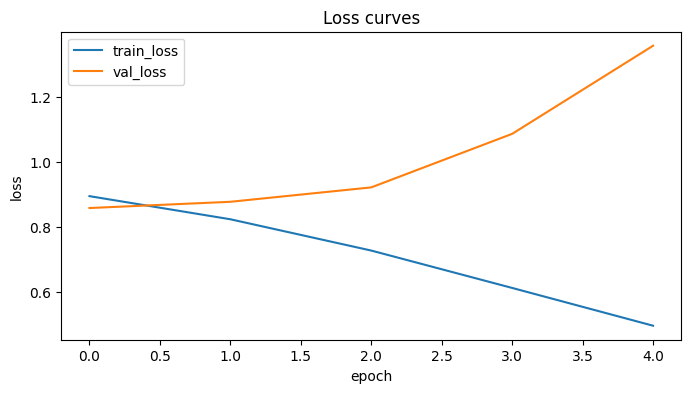

In [10]:
# Save training history and plot loss curves
import pandas as pd
import matplotlib.pyplot as plt
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(OUTPUT_DIR / 'history.csv', index=False)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss curves'); plt.xlabel('epoch'); plt.ylabel('loss')
plt.savefig(OUTPUT_DIR / 'loss_plot.png')
plt.show()

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           1     0.6935    0.3446    0.4604      1123
           2     0.0000    0.0000    0.0000       128
           3     0.0000    0.0000    0.0000       256
           4     0.0000    0.0000    0.0000      1122
           5     0.7305    0.9842    0.8386      5962

    accuracy                         0.7281      8591
   macro avg     0.2848    0.2658    0.2598      8591
weighted avg     0.5976    0.7281    0.6422      8591



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


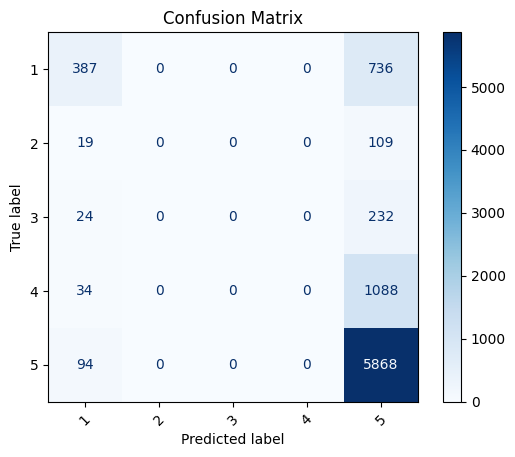

In [11]:
# Evaluation: classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
test_ds = make_ds(X_test, y_test, vectorize, batch_size=BATCH_SIZE, shuffle=False)
y_pred_raw = model.predict(test_ds)
if num_classes == 2:
    y_pred = (y_pred_raw.squeeze() >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_pred_raw, axis=1)

report = classification_report(y_test, y_pred, target_names=le.classes_, digits=4)
print(report)
with open(OUTPUT_DIR / 'classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png')
plt.show()

In [12]:
# Inference / smoke tests
def infer_texts(texts):
    cleaned = [clean_text(t) for t in texts]
    tokens = vectorize(tf.constant(cleaned))
    preds = model.predict(tokens)
    if num_classes == 2:
        labs = (preds.squeeze() >= 0.5).astype(int)
    else:
        labs = preds.argmax(axis=1)
    return [le.inverse_transform([lab])[0] for lab in labs]

examples = [
    "Agent resolved my issue quickly and politely.",
    "They charged me extra and refused refund — very disappointed."
]
print('Examples ->', infer_texts(examples))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
Examples -> ['5', '1']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [13]:
# Minimal assertions / smoke tests
assert len(X_train) > 0 and len(X_test) > 0, 'Train/test splits empty!'
_sample = infer_texts(['test message'])
assert _sample is not None, 'Inference returned None'
print('Smoke tests passed.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
Smoke tests passed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## Summary & Next Steps
- Model and artifacts saved to `outputs/`.
- Next steps: hyperparameter tuning (e.g., embedding_dim, LSTM units, learning rate), more preprocessing, class balancing, and explainability (SHAP).
- To reproduce exact environment, create `requirements.txt` and run in a virtualenv or colab with GPU if available.
